<a href="https://colab.research.google.com/github/kimcheese23/Data-analytics/blob/main/Code/Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
folder = '/content/drive/MyDrive/PTDL'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 1. File và thư viện

In [ ]:
# Thêm các thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df_raw = pd.read_csv('/content/drive/MyDrive/PTDL/GamingStudy_data.csv', encoding='latin1')
df_raw.head(5)

,S. No.,Timestamp,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,GADE,...,Birthplace,Residence,Reference,Playstyle,accept,GAD_T,SWL_T,SPIN_T,Residence_ISO3,Birthplace_ISO3
0,1,42052.00437,0,0,0,0,1,0,0,Not difficult at all,...,USA,USA,Reddit,Singleplayer,Accept,1,23,5.0,USA,USA
1,2,42052.00680,1,2,2,2,0,1,0,Somewhat difficult,...,USA,USA,Reddit,Multiplayer - online - with strangers,Accept,8,16,33.0,USA,USA
2,3,42052.03860,0,2,2,0,0,3,1,Not difficult at all,...,Germany,Germany,Reddit,Singleplayer,Accept,8,17,31.0,DEU,DEU
3,4,42052.06804,0,0,0,0,0,0,0,Not difficult at all,...,USA,USA,Reddit,Multiplayer - online - with online acquaintanc...,Accept,0,17,11.0,USA,USA
4,5,42052.08948,2,1,2,2,2,3,2,Very difficult,...,USA,South Korea,Reddit,Multiplayer - online - with strangers,Accept,14,14,13.0,KOR,USA


# 2. Khám phá dữ liệu (EDA)

In [ ]:
df = df_raw.copy()
print(f'Dữ liệu có {df.shape[0]} dòng quan sát và {df.shape[1]} cột thuộc tính.')
print(df.columns.tolist())

Dữ liệu có 13464 dòng quan sát và 55 cột thuộc tính.
['S. No.', 'Timestamp', 'GAD1', 'GAD2', 'GAD3', 'GAD4', 'GAD5', 'GAD6', 'GAD7', 'GADE', 'SWL1', 'SWL2', 'SWL3', 'SWL4', 'SWL5', 'Game', 'Platform', 'Hours', 'earnings', 'whyplay', 'League', 'highestleague', 'streams', 'SPIN1', 'SPIN2', 'SPIN3', 'SPIN4', 'SPIN5', 'SPIN6', 'SPIN7', 'SPIN8', 'SPIN9', 'SPIN10', 'SPIN11', 'SPIN12', 'SPIN13', 'SPIN14', 'SPIN15', 'SPIN16', 'SPIN17', 'Narcissism', 'Gender', 'Age', 'Work', 'Degree', 'Birthplace', 'Residence', 'Reference', 'Playstyle', 'accept', 'GAD_T', 'SWL_T', 'SPIN_T', 'Residence_ISO3', 'Birthplace_ISO3']


In [ ]:
def value_check(dataframe):
    dataframe_check = pd.DataFrame({
        'Count': dataframe.count(),
        'Unique': dataframe.nunique(),
        'Null': dataframe.isnull().sum(),
        '%Null': (dataframe.isnull().sum() / len(dataframe)) * 100,
        'DType': dataframe.dtypes.values
    })
    dataframe_check['%Null'] = dataframe_check['%Null'].map('{:.2f}%'.format)
    return dataframe_check.style

In [ ]:
value_check(df)

,Count,Unique,Null,%Null,DType
S. No.,13464,13464,0,0.00%,int64
Timestamp,13464,11734,0,0.00%,float64
GAD1,13464,4,0,0.00%,int64
GAD2,13464,4,0,0.00%,int64
GAD3,13464,4,0,0.00%,int64
GAD4,13464,4,0,0.00%,int64
GAD5,13464,4,0,0.00%,int64
GAD6,13464,4,0,0.00%,int64
GAD7,13464,4,0,0.00%,int64
GADE,12815,4,649,4.82%,object


In [ ]:
print('\nThống kê mô tả các biến định lượng:')
df.describe()


Thống kê mô tả các biến định lượng:


,S. No.,Timestamp,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,SWL1,...,SPIN13,SPIN14,SPIN15,SPIN16,SPIN17,Narcissism,Age,GAD_T,SWL_T,SPIN_T
count,13464.000000,13464.000000,13464.000000,13464.000000,13464.000000,13464.000000,13464.000000,13464.000000,13464.000000,13464.000000,...,13277.000000,13308.000000,13317.000000,13317.000000,13289.000000,13441.000000,13464.000000,13464.000000,13464.000000,12814.000000
mean,7096.839201,42054.841222,0.860963,0.673351,0.965761,0.724079,0.488042,0.911022,0.588755,3.720440,...,0.538827,1.252405,1.411054,0.620635,0.935962,2.027677,20.930407,5.211973,19.788844,19.848525
std,4114.478220,0.272948,0.926542,0.915724,0.982776,0.921971,0.837014,0.931168,0.894408,1.736264,...,0.944180,1.207463,1.349874,0.961853,1.180456,1.061842,3.300897,4.713267,7.229243,13.467493
min,1.000000,42052.004370,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,18.000000,0.000000,5.000000,0.000000
25%,3532.750000,42054.716548,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,18.000000,2.000000,14.000000,9.000000
50%,7087.500000,42054.800675,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,4.000000,...,0.000000,1.000000,1.000000,0.000000,0.000000,2.000000,20.000000,4.000000,20.000000,17.000000
75%,10654.250000,42054.932112,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,5.000000,...,1.000000,2.000000,2.000000,1.000000,2.000000,3.000000,22.000000,8.000000,26.000000,28.000000
max,14250.000000,42058.363750,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,7.000000,...,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,63.000000,21.000000,35.000000,68.000000


In [ ]:
df.describe(include=['O'])

,GADE,Game,Platform,earnings,whyplay,League,Gender,Work,Degree,Birthplace,Residence,Reference,Playstyle,accept,Residence_ISO3,Birthplace_ISO3
count,12815,13464,13464,13464,13464,11609,13464,13426,11887,13464,13464,13449,13464,13050,13354,13343
unique,4,11,3,312,403,1389,3,4,4,126,109,4,297,1,107,124
top,Not difficult at all,League of Legends,PC,I play for fun,having fun,Gold,Male,Student at college / university,High school diploma (or equivalent),USA,USA,Reddit,Multiplayer - online - with real life friends,Accept,USA,USA
freq,6236,11314,13219,12112,5289,1021,12699,7073,8560,4261,4569,13324,5564,13050,4569,4261


Thống kê

In [ ]:
print('\nPhân bố số lượng theo Giới tính:')
print(df['Gender'].value_counts())

print('\nPhân bố số lượng theo nền tảng chơi game.')
print(df['Platform'].value_counts())

print('\nPhân bố số lượng theo Tựa game chơi phổ biến:')
print(df['Game'].value_counts().head(10))

print('\nPhân bố số lượng theo Công việc:')
print(df['Work'].value_counts())

print('\nPhân bố số lượng theo Trình độ học vấn:')
print(df['Degree'].value_counts())


Phân bố số lượng theo Giới tính:
Gender
Male      12699
Female      713
Other        52
Name: count, dtype: int64

Phân bố số lượng theo nền tảng chơi game.
Platform
PC                         13219
Console (PS, Xbox, ...)      222
Smartphone / Tablet           23
Name: count, dtype: int64

Phân bố số lượng theo Tựa game chơi phổ biến:
Game
League of Legends      11314
Other                   1021
Starcraft 2              345
Counter Strike           318
World of Warcraft        152
Hearthstone              101
Diablo 3                  89
Heroes of the Storm       41
Guild Wars 2              37
Skyrim                    28
Name: count, dtype: int64

Phân bố số lượng theo Công việc:
Work
Student at college / university    7073
Employed                           2734
Student at school                  2229
Unemployed / between jobs          1390
Name: count, dtype: int64

Phân bố số lượng theo Trình độ học vấn:
Degree
High school diploma (or equivalent)        8560
BachelorÃÂÃÂÃÂ

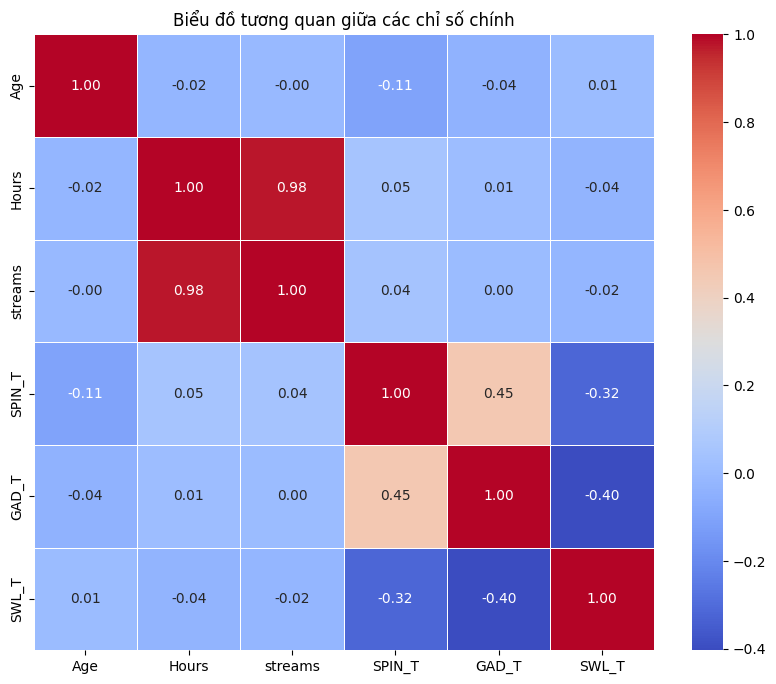

In [ ]:
core_columns = ['Age', 'Hours', 'streams', 'SPIN_T', 'GAD_T', 'SWL_T']

corr_matrix = df[core_columns].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Biểu đồ tương quan giữa các chỉ số chính')
plt.show()

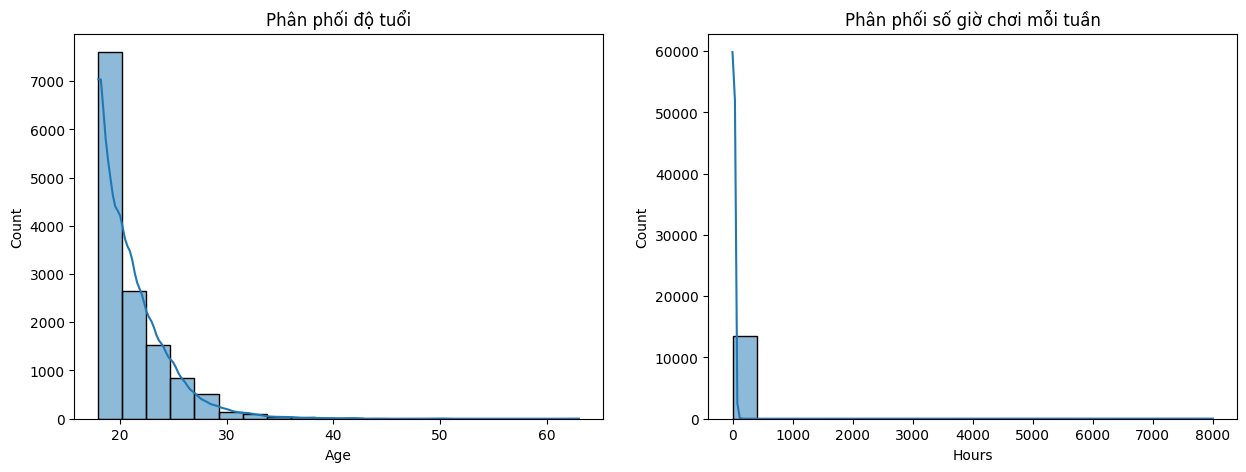

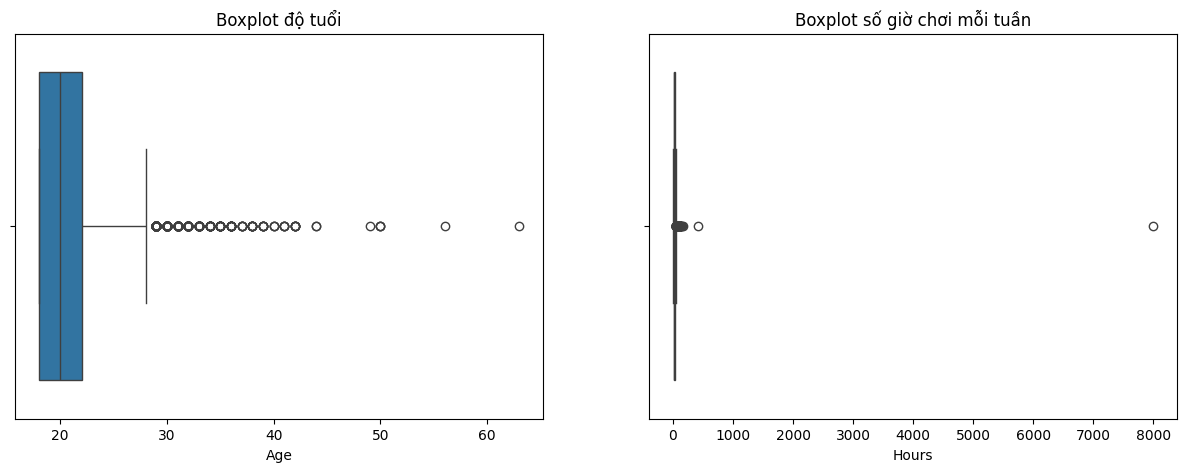

In [ ]:
# Vẽ biểu đồ phân phối
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df['Age'].dropna(), bins=20, ax=axes[0], kde=True)
axes[0].set_title('Phân phối độ tuổi')
sns.histplot(df['Hours'].dropna(), bins=20, ax=axes[1], kde=True)
axes[1].set_title('Phân phối số giờ chơi mỗi tuần')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(x=df['Age'], ax=axes[0])
axes[0].set_title('Boxplot độ tuổi')
sns.boxplot(x=df['Hours'], ax=axes[1])
axes[1].set_title('Boxplot số giờ chơi mỗi tuần')
plt.show()

In [ ]:
# Liệt kê các cột cần kiểm tra
gad_cols = ['GAD1', 'GAD2', 'GAD3', 'GAD4', 'GAD5', 'GAD6', 'GAD7']
swl_cols = ['SWL1', 'SWL2', 'SWL3', 'SWL4', 'SWL5']
spin_cols = ['SPIN1', 'SPIN2', 'SPIN3', 'SPIN4', 'SPIN5', 'SPIN6', 'SPIN7',
             'SPIN8', 'SPIN9', 'SPIN10', 'SPIN11', 'SPIN12', 'SPIN13',
             'SPIN14', 'SPIN15', 'SPIN16', 'SPIN17']

# Hàm kiểm tra nhanh
def check_scale_consistency(df, col_list, expected_min=0, expected_max=3, scale_name=''):
    print(f"\n=== Kiểm tra thang đo {scale_name} ===")
    print(f"Giá trị kỳ vọng: {expected_min} - {expected_max}")
    for col in col_list:
        if col in df.columns:
            min_val = df[col].min()
            max_val = df[col].max()
            unique_vals = df[col].unique()
            print(f"{col}: Min={min_val}, Max={max_val}, Số giá trị khác nhau={len(unique_vals)}")
            # Kiểm tra nếu có giá trị ngoài khoảng
            if min_val < expected_min or max_val > expected_max:
                print(f"  --> WARNING: Có giá trị nằm ngoài khoảng {expected_min}-{expected_max}!")

# Chạy kiểm tra
check_scale_consistency(df, gad_cols, 0, 3, 'GAD (Lo âu)')
check_scale_consistency(df, swl_cols, 1, 7, 'SWL (Sự hài lòng cuộc sống)')
check_scale_consistency(df, spin_cols, 0, 4, 'SPIN (Sợ xã hội)')

# Ngoài ra, kiểm tra các cột dạng phân loại khác
print("\n=== Giá trị duy nhất của cột 'GADE' ===")
print(df['GADE'].unique())
print("\n=== Giá trị duy nhất của cột 'Game' ===")
print(df['Game'].unique())


=== Kiểm tra thang đo GAD (Lo âu) ===
Giá trị kỳ vọng: 0 - 3
GAD1: Min=0, Max=3, Số giá trị khác nhau=4
GAD2: Min=0, Max=3, Số giá trị khác nhau=4
GAD3: Min=0, Max=3, Số giá trị khác nhau=4
GAD4: Min=0, Max=3, Số giá trị khác nhau=4
GAD5: Min=0, Max=3, Số giá trị khác nhau=4
GAD6: Min=0, Max=3, Số giá trị khác nhau=4
GAD7: Min=0, Max=3, Số giá trị khác nhau=4

=== Kiểm tra thang đo SWL (Sự hài lòng cuộc sống) ===
Giá trị kỳ vọng: 1 - 7
SWL1: Min=1, Max=7, Số giá trị khác nhau=7
SWL2: Min=1, Max=7, Số giá trị khác nhau=7
SWL3: Min=1, Max=7, Số giá trị khác nhau=7
SWL4: Min=1, Max=7, Số giá trị khác nhau=7
SWL5: Min=1, Max=7, Số giá trị khác nhau=7

=== Kiểm tra thang đo SPIN (Sợ xã hội) ===
Giá trị kỳ vọng: 0 - 4
SPIN1: Min=0.0, Max=4.0, Số giá trị khác nhau=6
SPIN2: Min=0.0, Max=4.0, Số giá trị khác nhau=6
SPIN3: Min=0.0, Max=4.0, Số giá trị khác nhau=6
SPIN4: Min=0.0, Max=4.0, Số giá trị khác nhau=6
SPIN5: Min=0.0, Max=4.0, Số giá trị khác nhau=6
SPIN6: Min=0.0, Max=4.0, Số giá trị k

# 3. Tiền xử lý dữ liệu

# 3. Lưu file

In [ ]:
df.to_csv(folder + '/GamingStudy_data.csv', index = False)